In [ ]:
!pip install ultralytics

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from folium.plugins import HeatMap

heat_data = [
    [13.08, 80.27],
    [13.081, 80.271],
    [13.082, 80.272]
]

HeatMap(heat_data).add_to(map)

map

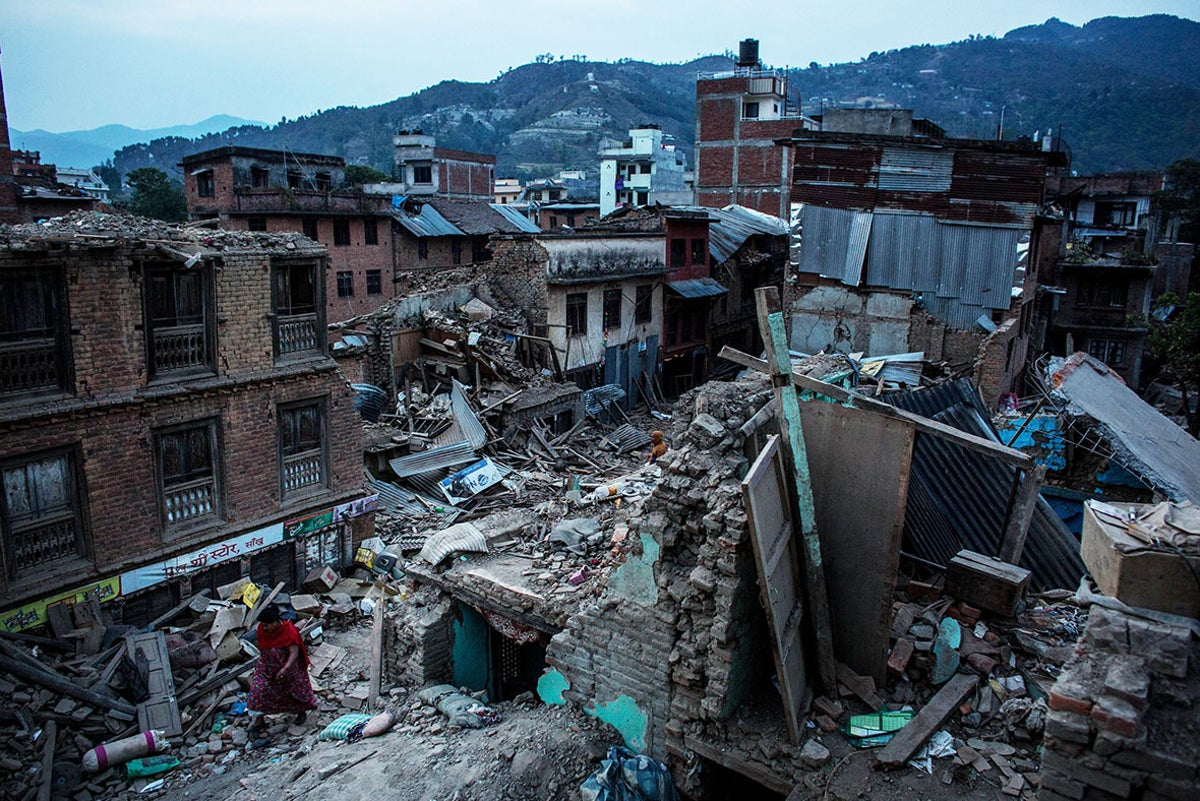

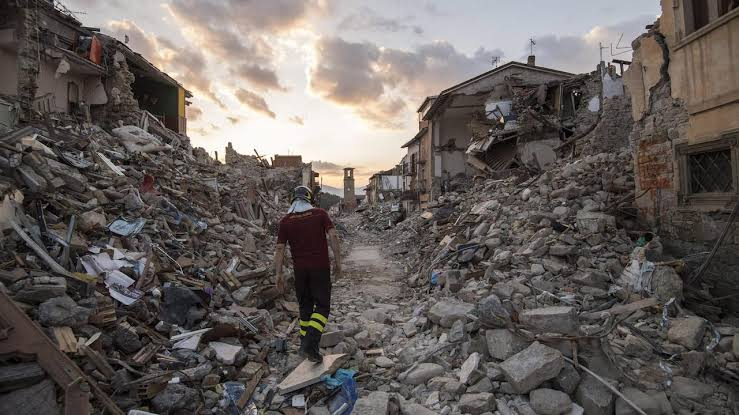

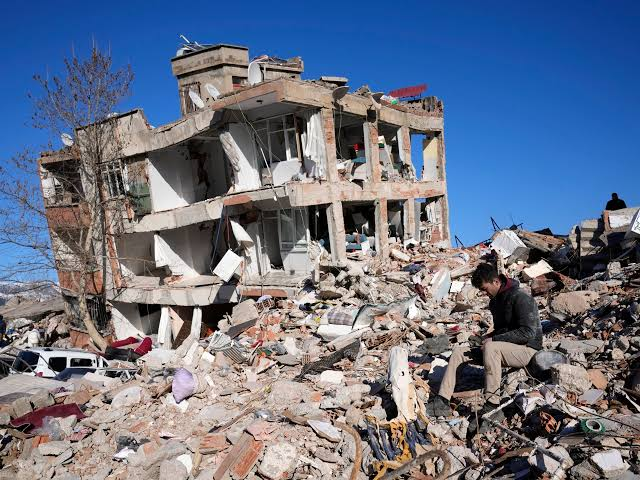

In [ ]:
from IPython.display import Image, display

images = ['image1.jpg', 'image2.jpeg', 'image3.jpeg']

for img in images:
    display(Image(filename=f'/content/{img}'))

In [ ]:
results = model('/content/image1.jpg', save=True)


image 1/1 /content/image1.jpg: 448x640 1 person, 8.3ms
Speed: 3.0ms preprocess, 8.3ms inference, 1.4ms postprocess per image at shape (1, 3, 448, 640)
Results saved to /content/runs/detect/predict2


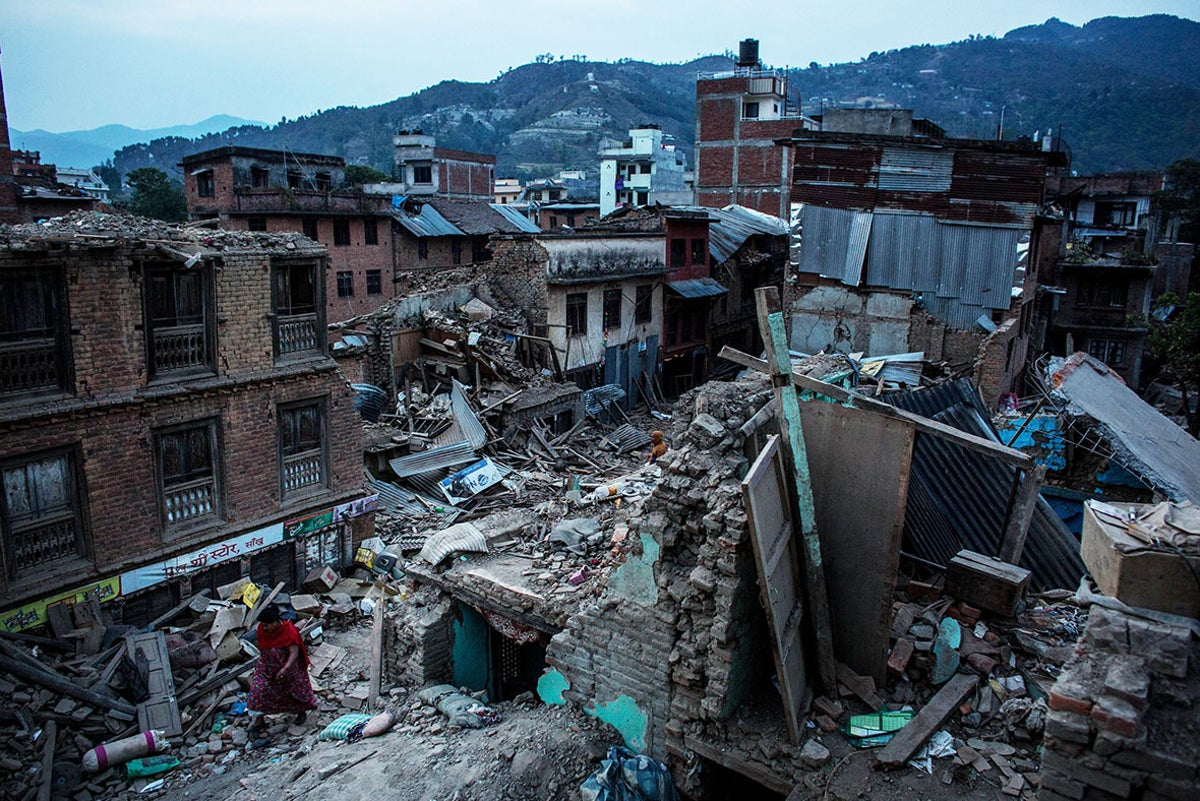

In [ ]:
display(Image(filename='/content/image1.jpg'))

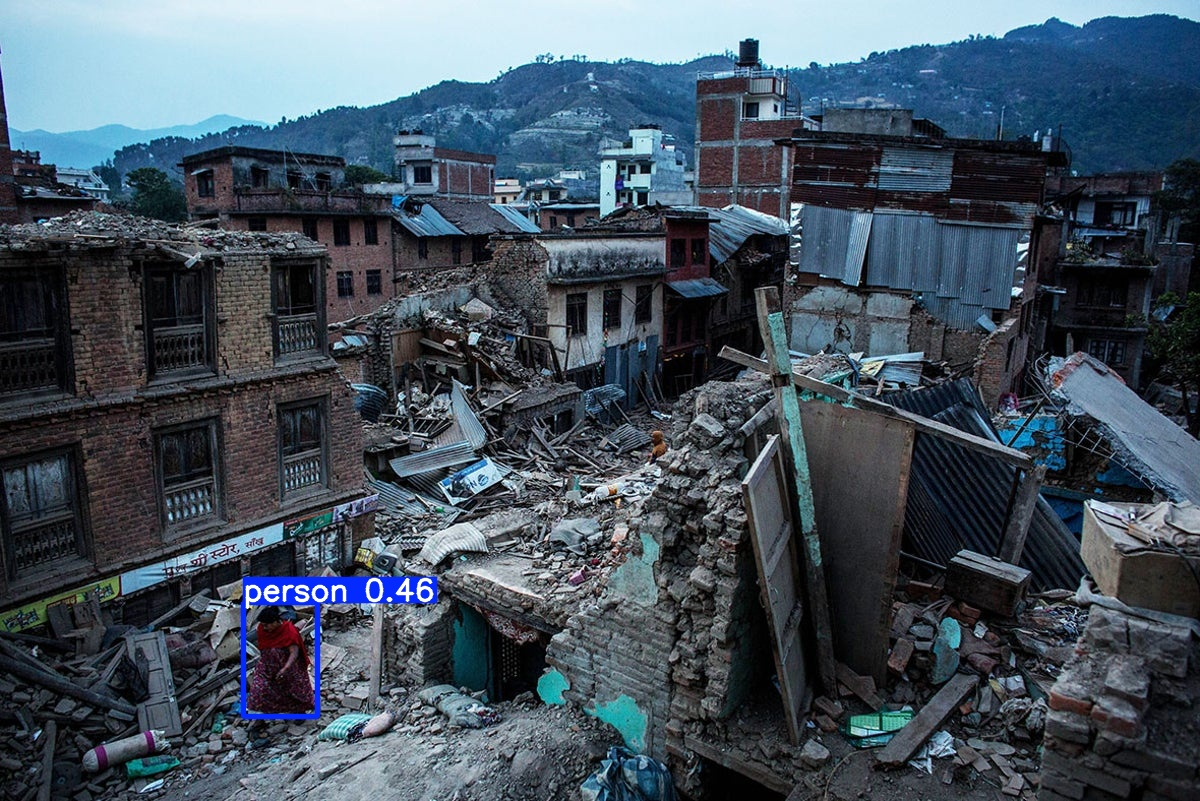

In [ ]:
import os
from IPython.display import Image, display

path = '/content/runs/detect'

for folder in os.listdir(path):
    files = os.listdir(f"{path}/{folder}")
    for file in files:
        display(Image(filename=f"{path}/{folder}/{file}"))

In [ ]:
import folium
from folium.plugins import HeatMap

# Create map
map = folium.Map(location=[20, 78], zoom_start=5)

images = ['image1.jpg', 'image2.jpeg', 'image3.jpeg']

locations = [
    [13.08, 80.27],
    [28.61, 77.20],
    [19.07, 72.87]
]

heat_data = []  # for heatmap

for i, img in enumerate(images):

    results = model(f'/content/{img}')

    # Detect objects
    detected = [results[0].names[int(i)] for i in results[0].boxes.cls]

    print(f"{img} detected:", detected)

    # Smart logic
    if "person" in detected and "car" in detected:
        damage = "Severe"
        color = "red"
        weight = 3
    elif "person" in detected:
        damage = "Moderate"
        color = "orange"
        weight = 2
    else:
        damage = "Minor"
        color = "green"
        weight = 1

    print(f"{img} → Damage: {damage}")

    lat, lon = locations[i]

    # Add marker
    folium.Marker(
        [lat, lon],
        popup=f"{img} → {damage}",
        icon=folium.Icon(color=color)
    ).add_to(map)

    # Add to heatmap data
    heat_data.append([lat, lon, weight])

# 🔥 Add heatmap layer
HeatMap(heat_data).add_to(map)

# Show map
map


image 1/1 /content/image1.jpg: 448x640 1 person, 26.1ms
Speed: 21.4ms preprocess, 26.1ms inference, 5.6ms postprocess per image at shape (1, 3, 448, 640)
image1.jpg detected: ['person']
image1.jpg → Damage: Moderate

image 1/1 /content/image2.jpeg: 384x640 1 person, 19.2ms
Speed: 5.4ms preprocess, 19.2ms inference, 3.9ms postprocess per image at shape (1, 3, 384, 640)
image2.jpeg detected: ['person']
image2.jpeg → Damage: Moderate

image 1/1 /content/image3.jpeg: 480x640 1 person, 1 car, 40.9ms
Speed: 7.6ms preprocess, 40.9ms inference, 4.5ms postprocess per image at shape (1, 3, 480, 640)
image3.jpeg detected: ['person', 'car']
image3.jpeg → Damage: Severe
